In [ ]:
# IMPORTS
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
'''
This notebook generates plots of the time-independent part of the study of the GAAH model.

Choose the folder with generated data by setting data_dir.
To save the generated data in any cell choose the folder name by setting out_dir.
Uncomment the desired cases and run the code.
'''

In [41]:
# Define initial parameters
data_dir = "data/nonzero_theta" # folder with the generated data
out_dir = "plots/nonzero_theta" # folder to save the plots

N = 34
theta = 1.4
v_list = [0.1, 0.5, 1.5]
sweep_lin = np.linspace(0, 2, 500) # sweep of V1(V2)
level_i = 21 # winding state: obtained from AAH_interactive_plot_phason_angle.py simulation

In [ ]:
# Define colors and labels for the plots - that was set for a specific cases of generated plots, change it accordingly if needed

# Line style per v-value, color per case (I / II / III)
linestyles = {0.1: "-", 0.5: "--", 1.5: ":"}
case_colors = {"I": "tab:blue", "II": "tab:orange", "III": "tab:green"}
case_labels = {"I": f"$V_2$=0", "II": f"$V_1$=0", "III": f"$V_1$=$V_2$"}
case_legend = {"I": f"$V_1$", "II": f"$V_2$", "III": f"V"}

# How V1/V2 map to v for each case
case_params = {
    "I":   lambda v: (v, 0.0),   # V1 = v, V2 = 0
    "II":  lambda v: (0.0, v),   # V1 = 0, V2 = v
    "III": lambda v: (v, v),     # V1 = v, V2 = v
}

params = []
for v1 in [0.1, 0.5, 1.5]:
    params.append(("I", v1, 0.0))
for v2 in [0.1, 0.5, 1.5]:
    params.append(("II", 0.0, v2))
for v in [0.1, 0.5, 1.5]:
    params.append(("III", v, v))

In [ ]:
# Helper functions
def load_data(quantity: str, V1: float, V2: float, theta: float = 0.0, lvl_i: int = level_i):
    """quantity is 'G' or 'dIPR'."""
    if quantity == "G":
        path = os.path.join(
            data_dir, f"GPhiSpectrum_N{N}_V1{V1}_V2{V2}_theta{theta}.npz"
        )
    else:
        path = os.path.join(
            data_dir,
            f"dIPRPhiSpectrum_N{N}_V1{V1}_V2{V2}_theta{theta}.npz",
        )
    d = np.load(path)
    return d[quantity], d["angles"]


def set_pi_ticks(ax):
    ax.set_xticks([0, 0.5, 1, 1.5, 2])
    ax.set_xticklabels(["0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
    ax.set_xlim(0, 2)


def save(fig, name):
    path = os.path.join(out_dir, name)
    fig.tight_layout()
    fig.savefig(path, dpi=150)
    plt.close(fig)
    print(f"Saved {path}")

In [ ]:
'''
G(phi)
To plot single datasets, uncomment the corresponding code and set the values for V1, V2 (and out_name for saving the plot).
Plots with many datasets displayed were set for the specific cases - modify accordingly.
'''

In [ ]:
### Single dataset plot

# out_name = "GPhiSpectrum.png"
# V1 = 0.5
# V2 = 0.0
# theta = 0.0
#
# fig, ax = plt.subplots(figsize=(7, 5))
# G, angles = load_data("G", V1, V2, theta)
# ax.plot(angles, G, linestyle='-', color='tab:blue', label=f"V1 = {V1}, V2 = {V2}")
# set_pi_ticks(ax)
# ax.set_xlabel(r"$\phi$")
# ax.set_ylabel("G/t")
# ax.set_title(f"G($\\phi$)")
# ax.text(0.5, -0.17, fr"N={N}, $\theta$ = {theta}, t=1.0", transform=ax.transAxes, ha="center", va="bottom")
# ax.legend(loc="best")
# ### Uncomment to save the figure
# # save(fig, out_name)
# plt.show()

##############################################################################################################
### Plot the cases seperately

for case, param_fn in case_params.items():
    fig, ax = plt.subplots(figsize=(7, 5))
    for v in v_list:
        V1, V2 = param_fn(v)
        G, angles = load_data("G", V1, V2, theta=theta)
        ax.plot(angles, G, linestyle=linestyles[v], color=case_colors[case],
                 label=f"{case_legend[case]} = {v}")
    set_pi_ticks(ax)
    ax.set_xlabel(r"$\phi$")
    ax.set_ylabel("G/t")
    ax.set_title(f"G($\\phi$),{case_labels[case]}")
    ax.text(0.5, -0.17, fr"N={N}, $\theta$ = {theta}, t=1.0", transform=ax.transAxes, ha="center", va="bottom")
    ax.legend(loc="right")

    ### Uncomment to save the figure
    save(fig, f"G_case_{case}.png")

    plt.show()

##############################################################################################################
### Plot all the cases together

# fig, ax = plt.subplots(figsize=(8, 6))
# for case, param_fn in case_params.items():
#     for v in v_list:
#         V1, V2 = param_fn(v)
#         G, angles = load_data("G", V1, V2)
#         ax.plot(angles, G, color=case_colors[case], linestyle=linestyles[v],
#                  label=f"{case_labels[case]}, {case_legend[case]} = {v}")
# set_pi_ticks(ax)
# ax.set_xlabel(r"$\phi$")
# ax.set_ylabel("G/t")
# ax.set_title(r"G($\phi$)")
# ax.text(0.5, -0.15, fr"N={N}, $\theta$ = {theta}, t=1.0", transform=ax.transAxes, ha="center", va="bottom")
# ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
# ### Uncomment to save the figure
# # save(fig, "G(phi).png")
# plt.show()


In [ ]:
'''
dIPR(phi).
To plot single datasets, uncomment the corresponding code and set the values for V1, V2 (and out_name for saving the plot).
Plots with many datasets displayed were set for the specific cases - modify accordingly.
'''

In [ ]:
### Single dataset plot

# out_name = "dIPRPhiSpectrum.png"
# V1 = 0.5
# V2 = 0.0
# theta = 0.0
#
# fig, ax = plt.subplots(figsize=(7, 5))
# dIPR, angles = load_data("dIPR", V1, V2, theta)
# ax.plot(angles, dIPR, linestyle='-', color='tab:blue', label=f"V1 = {V1}, V2 = {V2}")
# set_pi_ticks(ax)
# ax.set_xlabel(r"$\phi$")
# ax.set_ylabel("G/t")
# ax.set_title(f"G($\\phi$)")
# ax.text(0.5, -0.17, fr"N={N}, $\theta$ = {theta}, t=1.0", transform=ax.transAxes, ha="center", va="bottom")
# ax.legend(loc="best")
# ### Uncomment to save the figure
# # save(fig, out_name)
# plt.show()

##############################################################################################################
### Plot the cases seperately

# for case, param_fn in case_params.items():
#     fig, ax = plt.subplots(figsize=(7, 5))
#     for v in v_list:
#         V1, V2 = param_fn(v)
#         dIPR, angles = load_data("dIPR", V1, V2, theta=theta)
#         ax.plot(angles, dIPR, linestyle=linestyles[v], color=case_colors[case],
#                  label=f"{case_legend[case]} = {v}")
#     set_pi_ticks(ax)
#     ax.set_xlabel(r"$\phi$")
#     ax.set_ylabel("dIPR")
#     ax.set_title(f"dIPR($\\phi$),{case_labels[case]}")
#     ax.text(0.5, -0.17, fr"N={N}, $\theta$ = {theta}, t=1.0", transform=ax.transAxes, ha="center", va="bottom")
#     ax.legend()
#     ### Uncomment to save the figure
#     # save(fig, f"dIPR_case_{case}_theta{theta}.png")
#     plt.show()

##############################################################################################################
### Plot all the cases together

fig, ax = plt.subplots(figsize=(8, 6))
for case, param_fn in case_params.items():
    for v in v_list:
        V1, V2 = param_fn(v)
        dIPR, angles = load_data("dIPR", V1, V2, theta=theta)
        ax.plot(angles, dIPR, color=case_colors[case], linestyle=linestyles[v],
                 label=f"{case_labels[case]}, {case_legend[case]} = {v}")
set_pi_ticks(ax)
ax.set_xlabel(r"$\phi$")
ax.set_ylabel("dIPR")
ax.set_title(r"dIPR($\phi$) ")
ax.text(0.5, -0.17, fr"N={N}, $\theta$ = {theta}, t=1.0", transform=ax.transAxes, ha="center", va="bottom")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
### Uncomment to save the figure
save(fig, f"dIPR(phi)_all_theta{theta}.png")
plt.show()

In [ ]:
'''
Energy spectrum as a function of phason angle phi

To plot single datasets, uncomment the corresponding code and set the values for V1, V2, theta (and out_name for saving the plot)
Plots for all the cases were set for the specific cases - modify accordingly.
'''

In [ ]:
level_highlight = [level_i] # levels to highlight (default: level_i from the parameters set in the beginning)

##############################################################################################################
### Single dataset plot

### Set the parameters
# out_name = "EnergySpectrumPhasonAngle.png"
# V1 = 0.5
# V2 = 0.0
# ### Load data
# fname = f"data/EnergyPhiSpectrum_N{N}_V1{V1}_V2{V2}_theta{theta}.npz"
# if not os.path.exists(fname):
#     print(f"Skipping missing file: {fname}")
#     sys.exit()
# npz = np.load(fname)
# energies = npz["energies"]   # shape (len(phi_lin), N)
# angles = npz["angles"]       # phi / pi
#
# n_levels = energies.shape[1]
#
# ### Plot the energy spectrum
# plt.figure(figsize=(8, 5))
# for i in range(n_levels):
#     if i == level_highlight:
#         continue
#     plt.plot(angles, energies[:, i], color="grey", linewidth=0.5)
# plt.plot(angles, energies[:, level_highlight], color="tab:blue", linewidth=1.5)
# plt.xlabel(r"$\phi$/$\pi$")
# plt.ylabel("E/t")
# plt.suptitle(fr"Energy spectrum of the AAH as a function of $\phi$")
# plt.title(fr"N={N}, $V_1$={V1:.2f}, $V_2$={V2:.2f}, $\theta$={theta:.2f}", fontsize=10)
# plt.grid()
# ### Uncomment to save the figure
# # save(fig, out_name)
# plt.show()

##############################################################################################################
### Plot all the cases seperately

for case, V1, V2 in params:
    fname = f"data/EnergyPhiSpectrum_N{N}_V1{V1}_V2{V2}_theta{theta}.npz"

    if not os.path.exists(fname):
        print(f"Skipping missing file: {fname}")
        continue

    npz = np.load(fname)
    energies = npz["energies"]   # shape (len(phi_lin), N)
    angles = npz["angles"]       # phi / pi

    n_levels = energies.shape[1]

    plt.figure(figsize=(8, 5))

    # Plot all levels in grey, except the highlighted one
    for i in range(n_levels):
        if i == level_highlight:
            continue
        plt.plot(angles, energies[:, i], color="grey", linewidth=0.5)

    # Highlight level 21 on top, colored by case (I / II / III)
    plt.plot(angles, energies[:, level_highlight], color=case_colors[case], linewidth=1.5)
    plt.xlabel(r"$\phi$/$\pi$")
    plt.ylabel("E/t")
    plt.suptitle(fr"Energy spectrum of the AAH as a function of $\phi$")
    plt.title(fr"N={N}, $V_1$={V1:.2f}, $V_2$={V2:.2f}, $\theta$={theta:.2f}", fontsize=10)
    plt.grid()

    out_name = f"EnergyPhiSpectrum_V1{V1:.2f}_V2{V2:.2f}.png"
    ### Uncomment to save the figure
    # save(fig, out_name)
    plt.show()


##############################################################################################################
### Plot all the cases in one file

# n_rows, n_cols = 3, 3
# fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 12))
# axes = axes.flatten()
#
# for ax, (case, V1, V2) in zip(axes, params):
#     fname = f"data/EnergyPhiSpectrum_N{N}_V1{V1}_V2{V2}_theta{theta}.npz"
#
#     if not os.path.exists(fname):
#         print(f"Skipping missing file: {fname}")
#         ax.axis("off")
#         continue
#
#     npz = np.load(fname)
#     energies = npz["energies"]   # shape (len(phi_lin), N)
#     angles = npz["angles"]       # phi / pi
#
#     n_levels = energies.shape[1]
#
#     # Plot all levels in grey, except the highlighted one
#     for i in range(n_levels):
#         if i == level_i:
#             continue
#         ax.plot(angles, energies[:, i], color="grey", linewidth=0.5)
#
#     # Highlight the chosen level on top, colored by case (I / II / III)
#     ax.plot(angles, energies[:, level_i], color=case_colors[case], linewidth=1.5)
#
#     ax.set_xlabel(r"$\phi$/$\pi$")
#     ax.set_ylabel("E/t")
#     ax.set_title(fr"N={N}, $V_1$={V1:.2f}, $V_2$={V2:.2f}, $\theta$={theta:.2f}", fontsize=10)
#     ax.grid()
#
# fig.suptitle(r"Energy spectrum of the AAH as a function of $\phi$")
# fig.tight_layout()
#
# out_name = f"EnergyPhiSpectrum_grid_N{N}.pdf"
# ### Uncomment to save the figure
# # save(fig, out_name)
# plt.show()

In [ ]:
'''
Heatmap of the probability density as a function of phason angle phi

To plot single datasets, uncomment the corresponding code and set the values for V1, V2, theta (and out_name for saving the plot)
Plots for all the cases were set for the specific cases - modify accordingly.
'''

In [ ]:
### Single dataset plot

# out_name = f"ProbabilityDensityHeatmap.png"
# V1 = 0.5
# V2 = 0.0
#
# # Load data
# fname = f"{data_dir}/WavefunctionPhiSpectrum_N{N}_V1{V1}_V2{V2}_theta{theta}_level{level_i}.npz"
#
# if not os.path.exists(fname):
#     print(f"Skipping missing file: {fname}")
#     sys.exit()
#
# npz = np.load(fname)
# prob_density = npz["prob_density"]  # shape (len(phi_lin), N)
# phi_lin = npz["phi_lin"]
#
# # Create figure and axes object
# fig, ax = plt.subplots(figsize=(8, 5))
#
# im = ax.imshow(
#     prob_density.T,
#     aspect="auto",
#     origin="lower",
#     extent=[phi_lin[0], phi_lin[-1], 1, N],
#     cmap="viridis",
# )
#
# fig.colorbar(im, label=r"$|\psi|^2$")
# set_pi_ticks(ax)
# ax.set_xlabel(r"$\phi$")
# ax.set_ylabel("Site")
# plt.suptitle(fr"Probability density (winding state) vs $\phi$")
# plt.title(fr"N={N}, $V_1$={V1:.2f}, $V_2$={V2:.2f}, $\theta$={theta:.2f}", fontsize=10)
#
# out_name = f"ProbabilityDensityHeatmap_N{N}_V1{V1:.2f}_V2{V2:.2f}.png"
# ### Uncomment to save the figure using your save function
# # save(fig, out_name)
#
# plt.show()


##############################################################################################################
### Plot all the cases seperately

# for case, V1, V2 in params:
#     fname = f"{data_dir}/WavefunctionPhiSpectrum_N{N}_V1{V1}_V2{V2}_theta{theta}_level{level_i}.npz"
#
#     if not os.path.exists(fname):
#         print(f"Skipping missing file: {fname}")
#         continue
#
#     npz = np.load(fname)
#     prob_density = npz["prob_density"]  # shape (len(phi_lin), N)
#     phi_lin = npz["phi_lin"]
#
#     fig, ax = plt.subplots(figsize=(8, 5))
#
#     # vmin and vmax are omitted to let imshow normalize each dataset independently
#     im = ax.imshow(
#         prob_density.T,
#         aspect="auto",
#         origin="lower",
#         extent=[phi_lin[0], phi_lin[-1], 1, N],
#         cmap="viridis",
#     )
#     fig.colorbar(im, label=r"$|\psi|^2$")
#     set_pi_ticks(ax)
#     ax.set_xlabel(r"$\phi$")
#     ax.set_ylabel("Site")
#     plt.suptitle(fr"Probability density (winding state) vs $\phi$")
#     plt.title(fr"N={N}, $V_1$={V1:.2f}, $V_2$={V2:.2f}, $\theta$={theta:.2f}", fontsize=10)
#
#     out_name = f"ProbabilityDensityHeatmap_N{N}_V1{V1:.2f}_V2{V2:.2f}.png"
#     ### Uncomment to save the figure using your save function
#     # save(fig, out_name)
#     plt.show()


##############################################################################################################
### Plot all the cases in one file

n_rows, n_cols = 3, 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 12))
axes = axes.flatten()
for ax, (case, V1, V2) in zip(axes, params):
    fname = f"{data_dir}/WavefunctionPhiSpectrum_N{N}_V1{V1}_V2{V2}_theta{theta}_level{level_i}.npz"

    if not os.path.exists(fname):
        print(f"Skipping missing file: {fname}")
        ax.axis("off")
        continue

    npz = np.load(fname)
    prob_density = npz["prob_density"]  # shape (len(phi_lin), N)
    phi_lin = npz["phi_lin"]
    im = ax.imshow(
        prob_density.T,
        aspect="auto",
        origin="lower",
        extent=[phi_lin[0], phi_lin[-1], 1, N],
        cmap="viridis",
    )
    set_pi_ticks(ax)
    ax.set_xlabel(r"$\phi$")
    ax.set_ylabel("site number")
    ax.set_title(fr"N={N}, $V_1$={V1:.2f}, $V_2$={V2:.2f}, $\theta$={theta:.2f}", fontsize=10)
    fig.colorbar(im, ax=ax, label=r"$|\psi|^2$", shrink=0.8)
fig.suptitle(fr"Probability density vs $\phi$")
fig.tight_layout()
out_name = f"ProbabilityDensityHeatmap_grid_N{N}.pdf"
### Uncomment to save the figure using your save function
# save(fig, out_name)
fig.show()

In [ ]:
'''
Heatmaps of G/t

To plot single datasets, uncomment the corresponding code and set the values V1(V2) accordingly (and out_name for saving the plot)
Plots for all the cases were set for the specific cases - modify accordingly.
'''

In [ ]:
### Single dataset plot

# out_name = "GPhiHeatmap.png"
# sweep_variable = "V1"
# fixed_value = 0.1
#
# if sweep_variable == "V1":
#     V2 = fixed_value
#     path = f"{data_dir}/GPhiHeatmap_N{N}_V2{V2:.1f}_theta{theta}.npz"
#     ylabel = r"$V_1$"
#     title = fr"$V_2={V2:.1f}$"
#
# elif sweep_variable == "V2":
#     V1 = fixed_value
#     path = f"{data_dir}/GPhiHeatmap_N{N}_V1{V1:.1f}_theta{theta}.npz"
#     ylabel = r"$V_2$"
#     title = fr"$V_1={V1:.1f}$"
#
# elif sweep_variable == "V1=V2":
#     path = f"{data_dir}/GPhiHeatmap_N{N}_V1V2_theta{theta}.npz"
#     ylabel = r"$V_1=V_2$"
#     title = r"$V_1=V_2$"
#
# else:
#     raise ValueError("sweep_variable must be 'V1', 'V2', or 'V1=V2'")
#
# d = np.load(path)
#
# G_matrix = d["G_matrix"]
# phi_lin = d["phi_lin"]
# fig, ax = plt.subplots(figsize=(6, 5))
# im = ax.pcolormesh(
#     phi_lin,
#     sweep_lin,
#     G_matrix,
#     shading="auto",
#     cmap="viridis"
# )
# ax.set_xlabel(r"$\phi$")
# ax.set_ylabel(ylabel)
# ax.set_title(title, fontsize=11)
#
# fig.colorbar(im, ax=ax, label=r"$G/t$")
# fig.suptitle(
#     fr"Heatmap of $G/t$ vs $\phi$ ($N={N}$, $\theta={theta}$)",
#     fontsize=12
# )
# fig.tight_layout()
# # save(fig, out_name)
# plt.show()

##############################################################################################################
### That was set for a specific cases of generated plots

cases = []
for V2 in [0.1, 0.5, 1.5]:
    path = f"{data_dir}/GPhiHeatmap_N{N}_V2{V2:.1f}_theta{theta}.npz"
    cases.append(("I", path, sweep_lin, f"V2={V2:.1f}", "V1"))
for V1 in [0.1, 0.5, 1.5]:
    path = f"{data_dir}/GPhiHeatmap_N{N}_V1{V1:.1f}_theta{theta}.npz"
    cases.append(("II", path, sweep_lin, f"V1={V1:.1f}", "V2"))
path = f"{data_dir}/GPhiHeatmap_N{N}_V1V2_theta{theta}.npz"
cases.append(("III", path, sweep_lin, "V1 = V2", "V1 = V2"))
datasets = []
for case_type, path, y_vals, title, ylabel in cases:
    d = np.load(path)
    datasets.append({
        "G_matrix": d["G_matrix"],
        "phi_lin": d["phi_lin"],
        "y": y_vals,
        "title": title,
        "ylabel": ylabel,
    })

##############################################################################################################
### Plot all the cases seperately

# ### Uncomment to normalize all the colorbars uniformly
# # vmin = min(d["G_matrix"].min() for d in datasets)
# # vmax = max(d["G_matrix"].max() for d in datasets)

# for i, d in enumerate(datasets):
#     fig, ax = plt.subplots(figsize=(6, 5))
#     im = ax.pcolormesh(
#         d["phi_lin"], d["y"], d["G_matrix"],
#         shading="auto", cmap="viridis"
#         # vmin=vmin, vmax=vmax
#     )
#     ax.set_title(d["title"], fontsize=10)
#     ax.set_xlabel(r"$\phi$")
#     ax.set_ylabel(d["ylabel"])
#     fig.colorbar(im, ax=ax, label="G")
#
#     out_name = f"{data_dir}/GPhiHeatmap_case{i+1}.png"
#     # ### Uncomment to save the figure using your save function
#     # # save(fig, out_name)
#     # plt.show()


##############################################################################################################
### Plot all the cases in one file

n_rows, n_cols = 3, 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 14))
axes = axes.flatten()

# ### Uncomment to normalize all the colorbars uniformly
# # vmin = min(d["G_matrix"].min() for d in datasets)
# # vmax = max(d["G_matrix"].max() for d in datasets)

# Plot each dataset on the grid with independent normalization
for i, d in enumerate(datasets):
    ax = axes[i]
    im = ax.pcolormesh(
        d["phi_lin"], d["y"], d["G_matrix"],
        shading="auto", cmap="viridis"
        # vmin=vmin, vmax=vmax
    )

    # Apply custom pi ticks helper function
    # ax.set_xticks(xticks)
    # ax.set_xticklabels(xticklabels)

    ax.set_title(d["title"], fontsize=10)
    ax.set_xlabel(r"$\phi$")
    ax.set_ylabel(d["ylabel"])

    # Add individual colorbar for each subplot
    fig.colorbar(im, ax=ax, label="G", shrink=0.8)

# Turn off any unused axes in the 3x3 grid
for j in range(len(datasets), len(axes)):
    axes[j].axis("off")

fig.suptitle(fr"Heatmaps of $G/t$ vs $\phi$ (N={N}, $\theta$={theta})", fontsize=14)
fig.tight_layout()

out_name = f"GPhiHeatmap.png"

## Uncomment to save the figure using your save function
# save(fig, out_name)
plt.show()

In [ ]:
'''
Heatmaps of IPR

To plot single datasets, uncomment the corresponding code and set the values V1(V2) accordingly.
Plots for all the cases were set for the specific cases - modify accordingly.
'''

In [ ]:
### Single dataset plot

# out_name = "IPRPhiHeatmap.png"
# sweep_variable = "V1"
# fixed_value = 0.1
#
# if sweep_variable == "V1":
#     V2 = fixed_value
#     path = f"{data_dir}/IPRPhiHeatmap_N{N}_V2{V2:.1f}_theta{theta}.npz"
#     ylabel = r"$V_1$"
#     title = fr"$V_2={V2:.1f}$"
# elif sweep_variable == "V2":
#     V1 = fixed_value
#     path = f"{data_dir}/IPRPhiHeatmap_N{N}_V1{V1:.1f}_theta{theta}.npz"
#     ylabel = r"$V_2$"
#     title = fr"$V_1={V1:.1f}$"
# elif sweep_variable == "V1=V2":
#     path = f"{data_dir}/IPRPhiHeatmap_N{N}_V1V2_theta{theta}.npz"
#     ylabel = r"$V_1=V_2$"
#     title = r"$V_1=V_2$"
# else:
#     raise ValueError("sweep_variable must be 'V1', 'V2', or 'V1=V2'")
#
# d = np.load(path)
# IPR_matrix = d["IPR_matrix"]
# phi_lin = d["phi_lin"]
# fig, ax = plt.subplots(figsize=(6, 5))
# im = ax.pcolormesh(
#     phi_lin,
#     sweep_lin,
#     IPR_matrix,
#     shading="auto",
#     cmap="RdBu"
# )
# ax.set_xlabel(r"$\phi$")
# ax.set_ylabel(ylabel)
# ax.set_title(title, fontsize=11)
# fig.colorbar(im, ax=ax, label="dIPR")
# fig.suptitle(fr"Heatmap of IPR vs $\phi$ ($N={N}$, $\theta={theta}$)", fontsize=12)
# fig.tight_layout()
# ### Uncomment to save the figure using your save function
# # save(fig, out_name)
# plt.show()

##############################################################################################################
### That was set for a specific cases of generated plots

cases = []
for V2 in [0.1, 0.5, 1.5]:
    path = f"{data_dir}/IPRPhiHeatmap_N{N}_V2{V2:.1f}_theta{theta}.npz"
    cases.append(("I", path, sweep_lin, f"V2={V2:.1f}", "V1"))

for V1 in [0.1, 0.5, 1.5]:
    path = f"{data_dir}/IPRPhiHeatmap_N{N}_V1{V1:.1f}_theta{theta}.npz"
    cases.append(("II", path, sweep_lin, f"V1={V1:.1f}", "V2"))

path = f"{data_dir}/IPRPhiHeatmap_N{N}_V1V2_theta{theta}.npz"
cases.append(("III", path, sweep_lin, "V1 = V2", "V1 = V2"))

datasets = []
for case_type, path, y_vals, title, ylabel in cases:
    d = np.load(path)
    datasets.append({
        "IPR_matrix": d["IPR_matrix"],
        "phi_lin": d["phi_lin"],
        "y": y_vals,
        "title": title,
        "ylabel": ylabel,
    })

##############################################################################################################
### Plot all the cases seperately

# ### Uncomment to normalize all the colorbars uniformly
# # vmin = min(d["IPR_matrix"].min() for d in datasets)
# # vmax = max(d["IPR_matrix"].max() for d in datasets)

# for i, d in enumerate(datasets):
#     fig, ax = plt.subplots(figsize=(6, 5))
#
#     im = ax.pcolormesh(
#         d["phi_lin"],
#         d["y"],
#         d["IPR_matrix"],
#         shading="auto",
#         cmap="RdBu",
#         # vmin=vmin, vmax=vmax
#     )
#
#     ax.set_title(d["title"], fontsize=10)
#     ax.set_xlabel(r"$\phi$")
#     ax.set_ylabel(d["ylabel"])
#
#     fig.colorbar(im, ax=ax, label="dIPR")
#
#     out_name = f"{data_dir}/IPRPhiHeatmap_case{i+1}.png"
#     # save(fig, out_name)
#     # plt.show()

##############################################################################################################
### Plot all the cases in one file

n_rows, n_cols = 3, 3
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, 14)
)
axes = axes.flatten()

### Uncomment to normalize all the colorbars uniformly
# vmin = min(d["IPR_matrix"].min() for d in datasets)
# vmax = max(d["IPR_matrix"].max() for d in datasets)

im = None
for i, d in enumerate(datasets):
    ax = axes[i]
    im = ax.pcolormesh(
        d["phi_lin"],
        d["y"],
        d["IPR_matrix"],
        shading="auto",
        cmap="RdBu",
        # vmin=vmin, vmax=vmax
    )
    ax.set_title(d["title"], fontsize=10)
    ax.set_xlabel(r"$\phi$")
    ax.set_ylabel(d["ylabel"])
for j in range(len(datasets), len(axes)):
    axes[j].axis("off")

fig.colorbar(im, ax=axes.tolist(), label="dIPR", shrink=0.8)

fig.suptitle(fr"Heatmaps of IPR vs $\phi$ ($N={N}$, $\theta={theta}$)", fontsize=14)
out_name = f"IPRPhiHeatmap.png"
# save(fig, out_name)
plt.show()

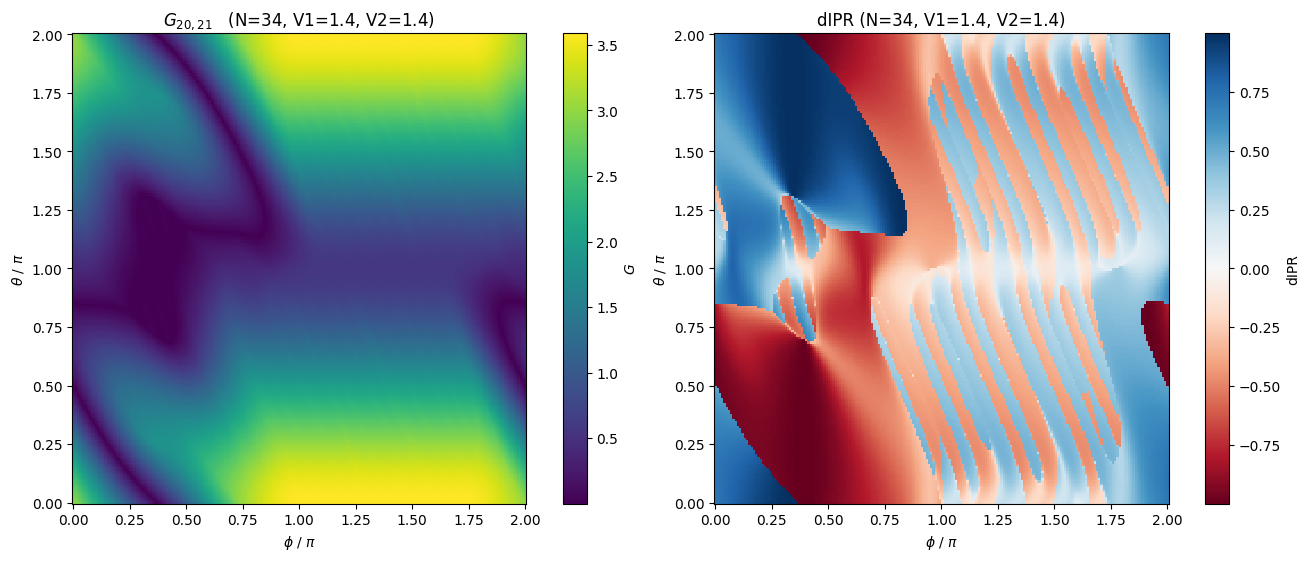

In [54]:
"""
Heatmap: Theta, Phi vs G.

To plot a datasets set the values of V1, V2 and filename accordingly
"""

V1=1.4
V2=V1

data_path = "data/nonzero_theta"
filename = f"G_dIPR_ThetaPhi_N{N}_V1{V1}_V2{V2}.npz"

full_path = os.path.join(data_path, filename)
data = np.load(full_path)

G_matrix = data["G_matrix"]
dIPR_matrix = data["dIPR_matrix"]
phi_lin = data["phi_lin"]
theta_lin = data["theta_lin"]
level_i = int(data["level_i"])
level_j = int(data["level_j"])

phi_over_pi = phi_lin / np.pi
theta_over_pi = theta_lin / np.pi


# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), constrained_layout=True)

im0 = axes[0].pcolormesh(
    phi_over_pi, theta_over_pi, G_matrix,
    shading="auto", cmap="viridis",
)
axes[0].set_title(rf"$G_{{{level_i},{level_j}}}$   (N={N}, V1={V1}, V2={V2})")
axes[0].set_xlabel(r"$\phi\ /\ \pi$")
axes[0].set_ylabel(r"$\theta\ /\ \pi$")
fig.colorbar(im0, ax=axes[0], label=r"$G$")

im1 = axes[1].pcolormesh(
    phi_over_pi, theta_over_pi, dIPR_matrix,
    shading="auto", cmap="RdBu",
)
axes[1].set_title(rf"dIPR (N={N}, V1={V1}, V2={V2})")
axes[1].set_xlabel(r"$\phi\ /\ \pi$")
axes[1].set_ylabel(r"$\theta\ /\ \pi$")
fig.colorbar(im1, ax=axes[1], label=r"dIPR")

out_path = "plots/nonzero_theta"
fig.savefig(os.path.join(out_path, f"Theta_phi_heatmap_N{N}_V1{V1}_V2{V2}.png"), dpi=200)
plt.show()
